In [2]:
from functools import partial
import matplotlib.pyplot as plt
import numpy as np
# BAYESFLOW
import bayesflow.diagnostics as diag
from bayesflow.amortizers import AmortizedPosterior
from bayesflow.networks import InvertibleNetwork
from bayesflow.simulation import GenerativeModel, Prior, Simulator
from bayesflow.trainers import Trainer
# TENSDORFLOW
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Conv2D, MaxPooling2D, TimeDistributed, Flatten, Dense
import tensorflow as tf
import sys
import seaborn as sns
import pandas as pd
import statsmodels as sm
import statsmodels.api as sm
import copy
from scipy.spatial.distance import pdist, squareform
from scipy.stats import mvn, gamma as xgamma, norm,multivariate_normal
from scipy.special import gamma, factorial
from timeit import default_timer as timer
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime

c:\Users\sparr\proyectos\parametrico\tf_env\lib\site-packages\bayesflow\trainers.py:27: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [3]:
from funciones import (
    preparar_datos_region,
    dividir_train_test,
    parametros_ubicaciones,
    preprocesamiento_escalar_datos,
    comprobar_dimensiones_ubic,
    procesamiento_matriz_diseno,
    simular_X1,
    simular_X3
)

def preparar_parametros_trainingYtesting(region, ruta_datos_precipitacion = 'tablas_precipitaciones.parquet', print_comprobacion_dimensiones = True):
    # Cargar datos de precipitaciones CHIRPS
    datos_precipitacion = pd.read_parquet(ruta_datos_precipitacion)

    # Filtrar datos para cada región
    datos_region = preparar_datos_region(datos_precipitacion, region)
    
    # Fecha corte para training
    fecha_corte_2018 = pd.to_datetime('2018-12-31')

    # Determinar parámetros relacionados con las ubicaciones
    ubic, n_sites, dist_mat = parametros_ubicaciones(datos_region)

    # Separar en training y testing
    datos_region_train, datos_region_test, m_train = dividir_train_test(datos_region, ubic, n_sites, fecha_corte_2018)

    # Determinar parámetros relacionados con las ubicaciones (training y testing)
    ubic_train, n_sites_train, dist_mat_train = parametros_ubicaciones(datos_region_train)

    # Constructores para estandarizar información
    poly_region, scaler_region = preprocesamiento_escalar_datos(datos_region_train)

    ## Datos de entrenamiento (reales)
    datos_region_train = datos_region_train.sort_values(['lat','lon','date'],ascending=[False,True,True])
    datos_region_train_pivot = datos_region_train.pivot(index='date',columns=['lat','lon'],values='chirps')

    ## Datos para prueba (reales)
    datos_region_test = datos_region_test.sort_values(['lat','lon','date'],ascending=[False,True,True])
    datos_region_test_pivot = datos_region_test.pivot(index='date',columns=['lat','lon'],values='chirps')

    # Matriz de diseño
    design_mat_train = procesamiento_matriz_diseno(datos_region_train, poly_region, scaler_region)
    design_mat_test = procesamiento_matriz_diseno(datos_region_test, poly_region, scaler_region)

    if print_comprobacion_dimensiones:
        print(comprobar_dimensiones_ubic(ubic_train, datos_region_train_pivot))

    return {
        "ubic": ubic,
        "nsites": n_sites,
        "dist_mat": dist_mat,
        "train": datos_region_train,
        "train_pivot": datos_region_train_pivot,
        "test": datos_region_test,
        "test_pivot": datos_region_test_pivot,
        "design_mat_train": design_mat_train,
        "design_mat_test": design_mat_test,
        "ubic_train": ubic_train,
        "n_sites_train": n_sites_train,
        "dist_mat_train": dist_mat_train,
        "m_train": m_train,
    }

parametros_region = preparar_parametros_trainingYtesting("Los Santos")

True


In [4]:
design_mat_train = parametros_region["design_mat_train"]
columnas_matriz_diseno = design_mat_train.columns.tolist()
dist_mat_train = parametros_region["dist_mat_train"]
n_sites_train = parametros_region["n_sites_train"]
n_gammas = design_mat_train.shape[1]
m_train = parametros_region["m_train"]
nombre_betas = [rf"beta_{col}" for col in columnas_matriz_diseno]

In [5]:
# Información sobre sistema
print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPUs:", tf.config.list_physical_devices("GPU"))
print("Build info:", tf.sysconfig.get_build_info())

# Configuración para permitir el uso de toda la GPU disponible
physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
    # Hacer visibles todas las GPUs disponibles
    tf.config.set_visible_devices(physical_devices, 'GPU')
    print(f"Se detectaron {len(physical_devices)} GPU(s) y se han configurado para su uso.")
    # Configurar para permitir el crecimiento dinámico de la memoria de cada GPU
    for device in physical_devices:
        tf.config.experimental.set_memory_growth(device, True)
else:
    print("No se detectaron GPUs.")

Python: 3.9.13 (tags/v3.9.13:6de2ca5, May 17 2022, 16:36:42) [MSC v.1929 64 bit (AMD64)]
TensorFlow: 2.10.1
Built with CUDA: True
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Build info: OrderedDict([('cpu_compiler', 'C:/Program Files (x86)/Microsoft Visual Studio/2019/Community/VC/Tools/MSVC/14.29.30133/bin/HostX64/x64/cl.exe'), ('cuda_compute_capabilities', ['sm_35', 'sm_50', 'sm_60', 'sm_70', 'sm_75', 'compute_80']), ('cuda_version', '64_112'), ('cudart_dll_name', 'cudart64_112.dll'), ('cudnn_dll_name', 'cudnn64_8.dll'), ('cudnn_version', '64_8'), ('is_cuda_build', True), ('is_rocm_build', False), ('is_tensorrt_build', False), ('msvcp_dll_names', 'msvcp140.dll,msvcp140_1.dll'), ('nvcuda_dll_name', 'nvcuda.dll')])
Se detectaron 1 GPU(s) y se han configurado para su uso.


In [6]:
# Configuración de la semilla para reproducibilidad
rng = np.random.default_rng(123)

import numpy as np
import pandas as pd

n_sitios = 10
n_obs = 120

# Coordenadas de cada sitio
lon_sitios = rng.uniform(-1, -0.5, size=n_sitios)
lat_sitios = rng.uniform(0.5, 1, size=n_sitios)

# Variables por sitio
dummy = rng.integers(0, 2, size=n_sitios)

# Matriz de covariables espaciales
X = pd.DataFrame({
    "intercepto": np.ones(n_sitios),
    "dummy": dummy,
    "lon": lon_sitios,
    "lat": lat_sitios,
})

# Betas espaciales verdaderos
beta = np.array([3, 0.2, -0.05, 0.05, 2])

# Efecto espacial de cada sitio
# Resultado: (10,)
efecto_espacial = X.values @ beta[0:4]

# Efecto temporal común
oscilacion_base = np.sin(np.linspace(0, 2*np.pi, n_obs))

# Efecto temporal + espacial
# Broadcasting:
elevar = oscilacion_base[:, None] * np.array(beta[4:5]) + efecto_espacial[None, :]

# Datos sintéticos
Y = np.exp(elevar)# + rng.normal(0, 0.1, size=(n_obs, n_sitios))

print("X:", X.shape)
print("Y:", Y.shape)

X: (10, 4)
Y: (120, 10)


In [7]:
def model_prior():
    betas = rng.normal(loc=0, scale=3, size=n_gammas)
    return betas

prior = Prior(prior_fun=model_prior, param_names=nombre_betas)
prior_means, prior_stds = prior.estimate_means_and_stds()
print("Medias del prior:", prior_means)

Medias del prior: [[ 0.01087809 -0.00218711  0.02437069  0.00048787 -0.02669533 -0.02706706
   0.02880526 -0.03820462 -0.0489244   0.03357971  0.07638792  0.00128296
  -0.04394044  0.29357974]]


In [8]:
def proceso_D8(beta_params):
    # Procesos comunes para todos los sitios
    alpha_auxiliar_long = np.exp(design_mat_train @ beta_params)
    alpha_auxiliar = alpha_auxiliar_long.to_numpy().reshape(n_sites_train, m_train).T # m_train x n_sites_train

    # Cota superior para el parámetro de correlación espacial
    rho_upper_range = 2*np.max(dist_mat_train)

    # Parámetro de desviación estándar para lognormal
    delta_auxiliar = np.random.uniform(0,3)
    # Beta3: Parámetro de la distribución marginal de X_3t(s) Gamma Inversa
    beta3_auxiliar = np.random.uniform(2,50)
    # Rho: Parámetro de la correlación espacial de X_3t(s)
    rho_auxiliar =  np.random.uniform(0,rho_upper_range)

    X1 = simular_X1(m_train, delta_auxiliar, n_sites_train) # m_train x n_sites_train
    X3 = simular_X3(m_train, rho_auxiliar, beta3_auxiliar, n_sites_train, dist_mat_train) # m_train x n_sites_train

    # X1 = np.ones((m_train, n_sites_train))
    # X3 = np.ones((m_train, n_sites_train))

    # Datos sintéticos
    Y_sintetico = alpha_auxiliar * X1 * X3
    # [Y, delta_auxiliar, phi_auxiliar, sigma_auxiliar, beta3_auxiliar, rho_auxiliar]
    return(Y_sintetico)

simulator_D8 = Simulator(simulator_fun=partial(proceso_D8))
model_D8 = GenerativeModel(prior, simulator_D8, name="simulador_proceso")
data_D8 = model_D8(batch_size=1)

# print('Inicia simulacion')
# myobj=datetime.now()
# print(myobj)
# Subir a 250.000
# simul_previa_D8 = model_D8(batch_size=15000)
# print('Termina simulacion')
# myobj=datetime.now()
# print(myobj)

INFO:root:Performing 2 pilot runs with the simulador_proceso model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 14)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 228, 36)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.


In [9]:
class CustomLSTM_D8(tf.keras.Model):
    def __init__(self, hidden_size=512, summary_dim=512):
        super().__init__()
        timesteps = m_train
        features = n_sites_train
        self.LSTM = tf.keras.Sequential(
            [   tf.keras.layers.Input((timesteps, features)),
                tf.keras.layers.LSTM(hidden_size, return_sequences=True),
                tf.keras.layers.LSTM(hidden_size, return_sequences=False),
 #               tf.keras.layers.Flatten(),
                tf.keras.layers.Dense(hidden_size, activation="relu"),
                tf.keras.layers.Dense(summary_dim, activation="elu"),
            ]
        )
 
    def call(self, x, **kwargs):
        x = tf.reshape(x, (-1, m_train, n_sites_train))
        out = self.LSTM(x)
        return out

In [10]:
COUPLING_NET_SETTINGS = {
    # "dense_args": dict(units=128, kernel_regularizer=None, activation="relu"),
    "num_dense": 2,
    "dropout_prob": 0.2, "bins" : 32
}
# SUBIR a 1024, 1024
# 128, 1024
summary_net_D8 = CustomLSTM_D8(hidden_size=128, summary_dim=1024)
inference_net_D8 = InvertibleNetwork(num_params=n_gammas, num_coupling_layers=4, coupling_settings=COUPLING_NET_SETTINGS, coupling_design='spline')
amortizer_D8 = AmortizedPosterior(inference_net_D8, summary_net_D8)
trainer_D8 = Trainer(amortizer=amortizer_D8, generative_model=model_D8, memory=False, checkpoint_path="checkpoints/trainer_D8_checkpoint")

INFO:root:Loaded loss history from checkpoints/trainer_D8_checkpoint\history_50.pkl.
INFO:root:Networks loaded from checkpoints/trainer_D8_checkpoint\ckpt-50
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [ ]:
# Probar 50 epochs
n_epochs = 50
n_batch_size = 128

# la corrida duro casi 72 horas
# history_D8 = trainer_D8.train_online(epochs=n_epochs, iterations_per_epoch=2000, batch_size=n_batch_size, early_stopping=True, validation_sims=128)
valid_sim_data_raw_D8 = model_D8(batch_size=n_batch_size)
valid_sim_data_D8 = trainer_D8.configurator(valid_sim_data_raw_D8)
posterior_samples_D8 = amortizer_D8.sample(valid_sim_data_D8, n_samples=100)

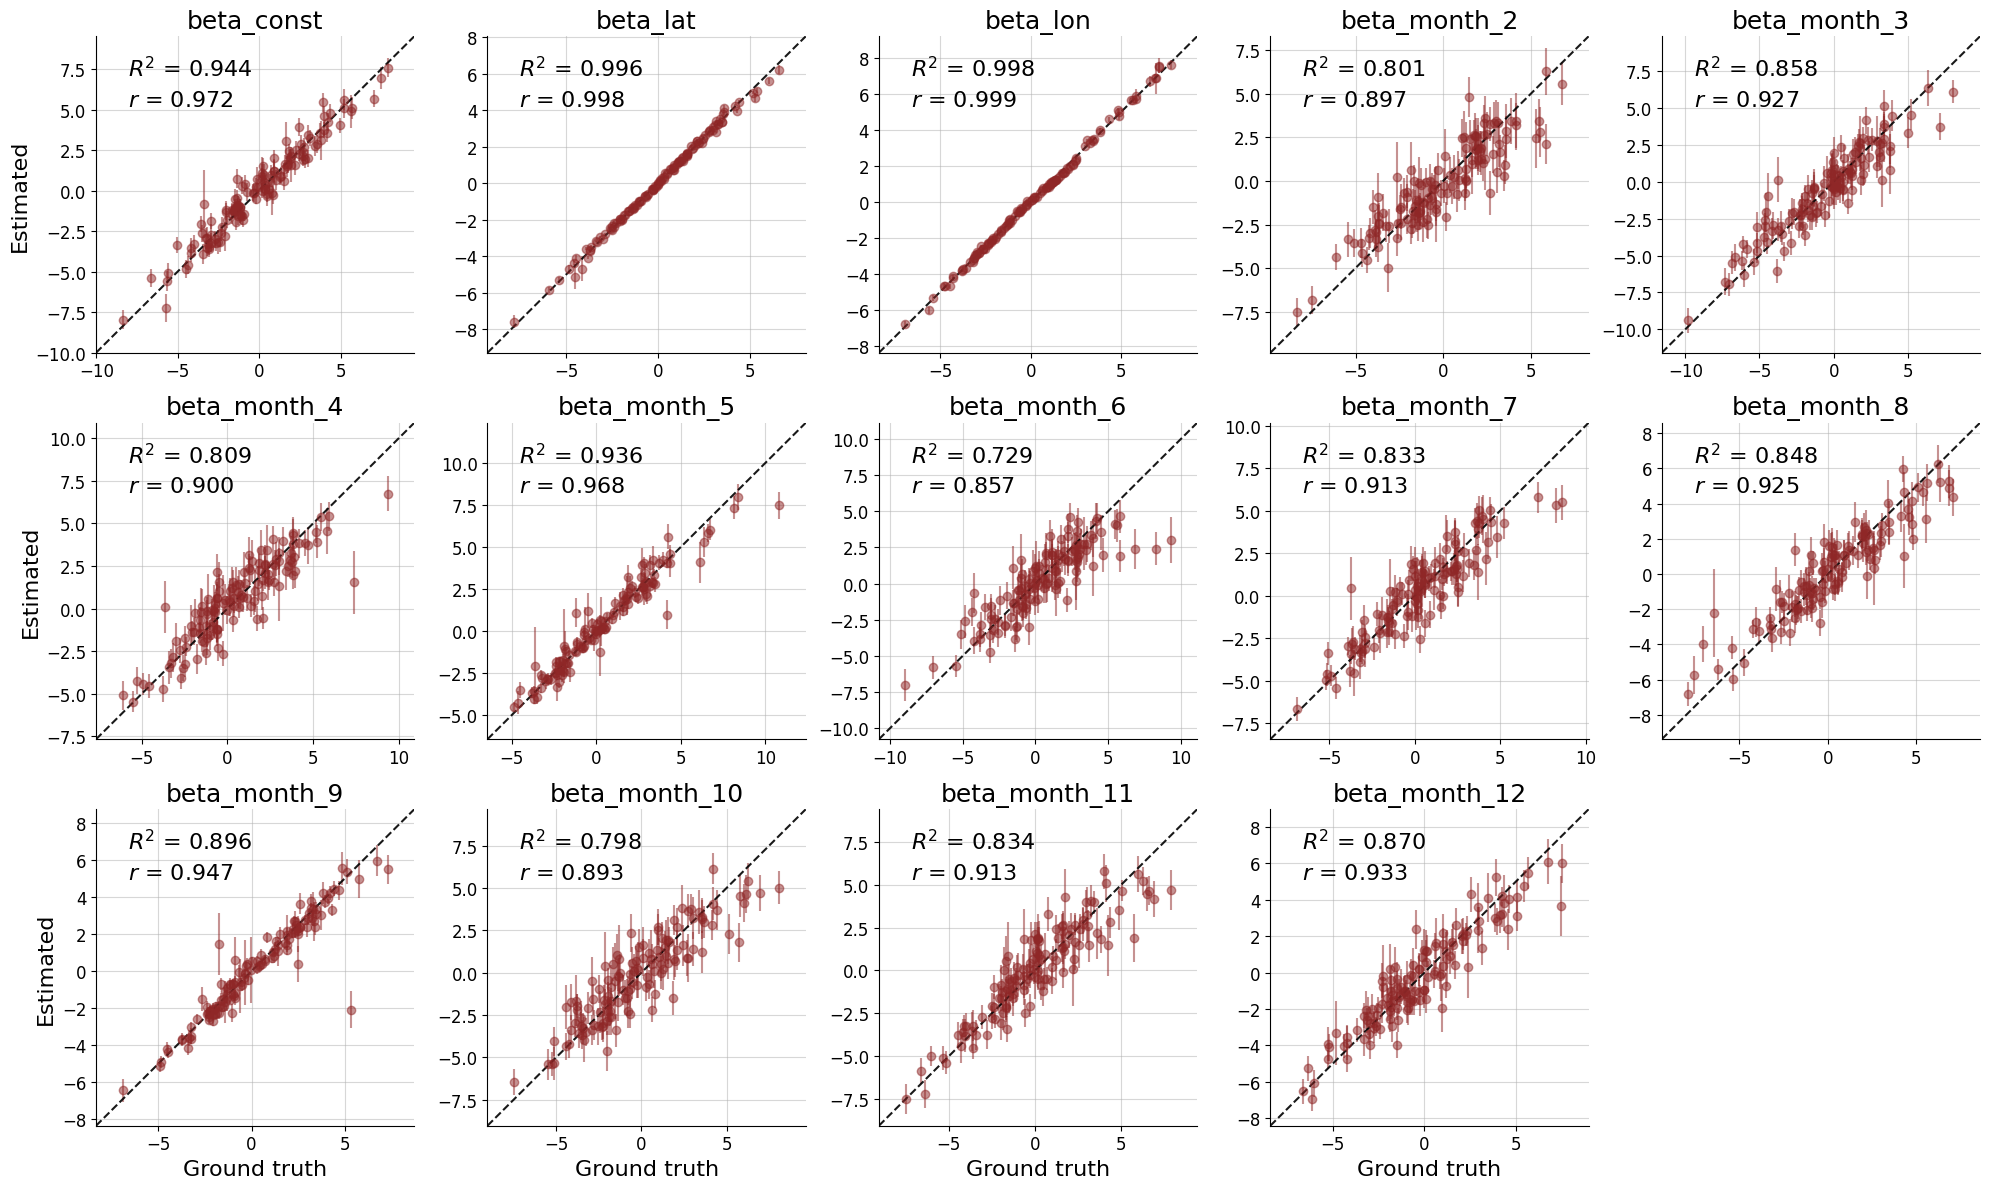

In [13]:
fig = diag.plot_recovery(posterior_samples_D8, valid_sim_data_D8["parameters"], param_names=nombre_betas, n_col=5)

In [14]:
Y_train = parametros_region["train_pivot"].to_numpy().astype("float32")

valid_sim_data_1 = model_D8(batch_size=1)

x = tf.expand_dims(Y_train, axis=0)

valid_sim_data_1["sim_data"] = x

valid_sim_data_1_c = trainer_D8.configurator(valid_sim_data_1)

posterior_samples = amortizer_D8.sample(
    valid_sim_data_1_c,
    n_samples=1000
)
media_posterior_samples = posterior_samples.mean(axis=0)

In [16]:
print(pd.DataFrame(posterior_samples).describe())

                0            1            2            3            4   \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean      3.797692    -0.101125    -0.085075    -0.591974    -0.770075   
std       0.730987     0.051971     0.054069     1.258624     1.040557   
min       1.999321    -0.300219    -0.274933    -4.352982    -4.284818   
25%       3.281176    -0.136054    -0.119593    -1.477783    -1.499512   
50%       3.762231    -0.100972    -0.084832    -0.494378    -0.704768   
75%       4.251598    -0.068250    -0.052084     0.246273    -0.040422   
max       6.630852     0.061704     0.090073     3.227329     2.758381   

                5            6            7            8            9   \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean     -0.581141     1.994747     2.367590     1.774235     0.091008   
std       0.998179     0.423387     1.397932     1.138885     0.990930   
min      -4.296679     0.770616    -2

In [17]:
media_posterior_samples

array([ 3.7976916 , -0.10112493, -0.08507504, -0.5919741 , -0.77007556,
       -0.5811414 ,  1.9947466 ,  2.3675902 ,  1.7742374 ,  0.09100819,
        1.819487  ,  2.632132  ,  1.6206667 , -1.0287817 ], dtype=float32)

In [ ]:
beta = np.array([3, 0.2, -0.05, 0.05, 2])
